# Online Payment Fraud Detection
### Exploratory Data Science using Python & Seaborn

## Project Introduction

Online payment systems are increasingly vulnerable to fraudulent transactions.
Detecting fraud patterns is essential for improving financial security.

This project explores online payment transaction data using exploratory
data science techniques to identify patterns associated with fraudulent activities.

The analysis focuses on customer behaviour, transaction characteristics,
and risk indicators using data visualization.

## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

import warnings
warnings.filterwarnings("ignore")

## Load Dataset

In [2]:
df = pd.read_csv("online_payment_fraud_eda_template.csv")
df.head()

,transaction_id,customer_id,transaction_type,payment_method,device_type,browser,transaction_amount,transaction_hour,transaction_day,location_country,is_foreign_transaction,previous_fraud_flag,customer_account_age_days,num_prev_transactions,avg_transaction_amount,ip_address_risk_score,merchant_category,transaction_status,is_weekend,fraud_flag
0,T100000,C1103,cash_out,Wallet,Mobile,Opera,1894.83,2,Sun,India,1,0,406,189,287.29,0.305,Travel,Failed,0,0
1,T100001,C1093,debit,Net Banking,Mobile,Edge,310.94,17,Mon,Germany,0,0,634,353,1205.94,0.213,Travel,Success,0,0
2,T100002,C1015,transfer,Credit Card,Tablet,Safari,1174.53,4,Fri,Germany,0,0,114,184,692.70,0.033,Food,Failed,0,0
3,T100003,C1107,payment,UPI,Desktop,Edge,1014.25,11,Wed,UK,1,0,201,3,729.62,0.304,Food,Success,0,0
4,T100004,C1072,debit,Net Banking,Tablet,Safari,1224.85,11,Wed,Singapore,0,0,26,191,208.89,0.653,E-commerce,Success,1,0


## Dataset Overview

In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             200 non-null    object 
 1   customer_id                200 non-null    object 
 2   transaction_type           200 non-null    object 
 3   payment_method             200 non-null    object 
 4   device_type                200 non-null    object 
 5   browser                    200 non-null    object 
 6   transaction_amount         200 non-null    float64
 7   transaction_hour           200 non-null    int64  
 8   transaction_day            200 non-null    object 
 9   location_country           200 non-null    object 
 10  is_foreign_transaction     200 non-null    int64  
 11  previous_fraud_flag        200 non-null    int64  
 12  customer_account_age_days  200 non-null    int64  
 13  num_prev_transactions      200 non-null    int64  

,transaction_amount,transaction_hour,is_foreign_transaction,previous_fraud_flag,customer_account_age_days,num_prev_transactions,avg_transaction_amount,ip_address_risk_score,is_weekend,fraud_flag
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,936.902600,11.720000,0.205000,0.100000,919.540000,231.505000,761.642850,0.487410,0.520000,0.080000
std,572.436623,6.764644,0.404715,0.300753,583.053234,144.579619,427.952142,0.288685,0.500854,0.271974
min,14.240000,0.000000,0.000000,0.000000,26.000000,3.000000,28.790000,0.002000,0.000000,0.000000
25%,422.752500,6.000000,0.000000,0.000000,405.000000,111.750000,375.352500,0.271250,0.000000,0.000000
50%,907.395000,12.000000,0.000000,0.000000,849.500000,222.000000,768.195000,0.500000,1.000000,0.000000
75%,1382.475000,17.000000,0.000000,0.000000,1436.250000,362.000000,1138.545000,0.724750,1.000000,0.000000
max,1993.760000,23.000000,1.000000,1.000000,1989.000000,499.000000,1477.630000,0.995000,1.000000,1.000000


## Missing Value Analysis

In [4]:
df.isnull().sum()

transaction_id               0
customer_id                  0
transaction_type             0
payment_method               0
device_type                  0
browser                      0
transaction_amount           0
transaction_hour             0
transaction_day              0
location_country             0
is_foreign_transaction       0
previous_fraud_flag          0
customer_account_age_days    0
num_prev_transactions        0
avg_transaction_amount       0
ip_address_risk_score        0
merchant_category            0
transaction_status           0
is_weekend                   0
fraud_flag                   0
dtype: int64

## Feature Engineering

Creating additional variables to improve fraud pattern detection

In [5]:
# High value transaction flag
df["high_value_transaction"] = df["transaction_amount"] > 1000

# Night transaction flag
df["night_transaction"] = df["transaction_hour"].apply(
    lambda x: 1 if x >= 22 or x <= 5 else 0
)

# Fraud risk score
df["fraud_risk_score"] = (
    df["ip_address_risk_score"] * 0.5 +
    df["is_foreign_transaction"] * 0.3 +
    df["previous_fraud_flag"] * 0.2
)

df.head()

,transaction_id,customer_id,transaction_type,payment_method,device_type,browser,transaction_amount,transaction_hour,transaction_day,location_country,...,num_prev_transactions,avg_transaction_amount,ip_address_risk_score,merchant_category,transaction_status,is_weekend,fraud_flag,high_value_transaction,night_transaction,fraud_risk_score
0,T100000,C1103,cash_out,Wallet,Mobile,Opera,1894.83,2,Sun,India,...,189,287.29,0.305,Travel,Failed,0,0,True,1,0.4525
1,T100001,C1093,debit,Net Banking,Mobile,Edge,310.94,17,Mon,Germany,...,353,1205.94,0.213,Travel,Success,0,0,False,0,0.1065
2,T100002,C1015,transfer,Credit Card,Tablet,Safari,1174.53,4,Fri,Germany,...,184,692.70,0.033,Food,Failed,0,0,True,1,0.0165
3,T100003,C1107,payment,UPI,Desktop,Edge,1014.25,11,Wed,UK,...,3,729.62,0.304,Food,Success,0,0,True,0,0.4520
4,T100004,C1072,debit,Net Banking,Tablet,Safari,1224.85,11,Wed,Singapore,...,191,208.89,0.653,E-commerce,Success,1,0,True,0,0.3265


## Fraud vs Non-Fraud Distribution

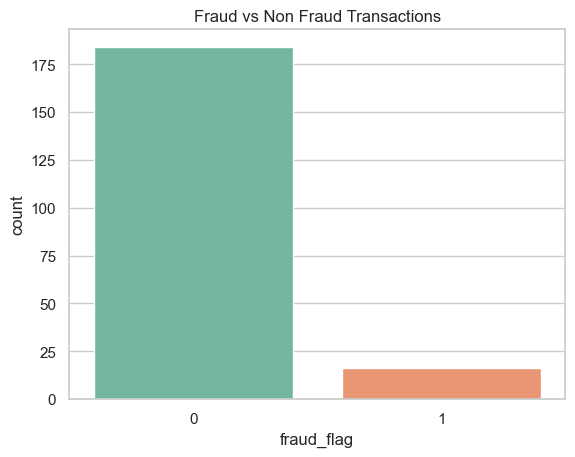

In [6]:
sns.countplot(data=df, x="fraud_flag", palette="Set2")
plt.title("Fraud vs Non Fraud Transactions")
plt.show()

## Transaction Amount Distribution

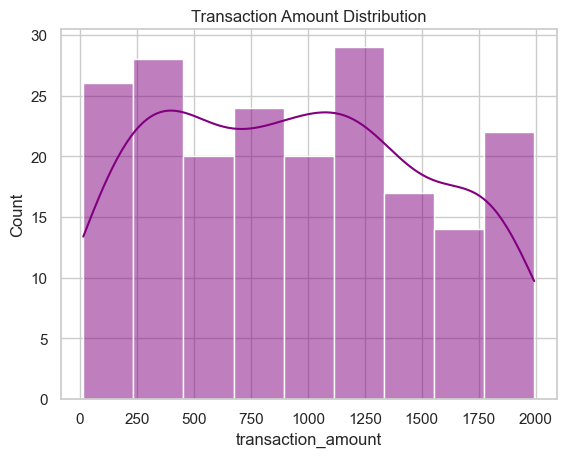

In [7]:
sns.histplot(df["transaction_amount"], kde=True, color="purple")
plt.title("Transaction Amount Distribution")
plt.show()

## Fraud by Payment Method

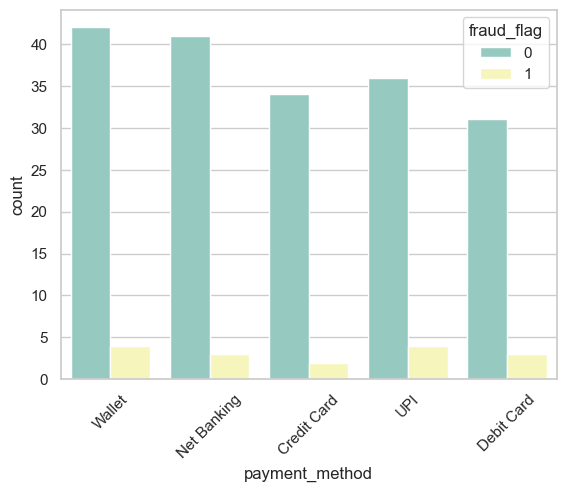

In [8]:
sns.countplot(data=df, x="payment_method", hue="fraud_flag", palette="Set3")
plt.xticks(rotation=45)
plt.show()

## Fraud by Device Type

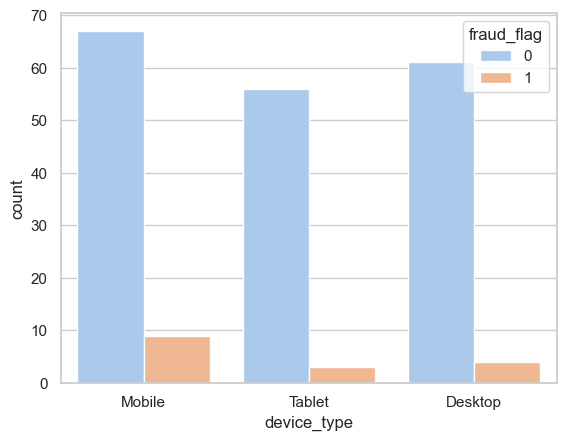

In [9]:
sns.countplot(data=df, x="device_type", hue="fraud_flag", palette="pastel")
plt.show()

## Fraud by Merchant Category

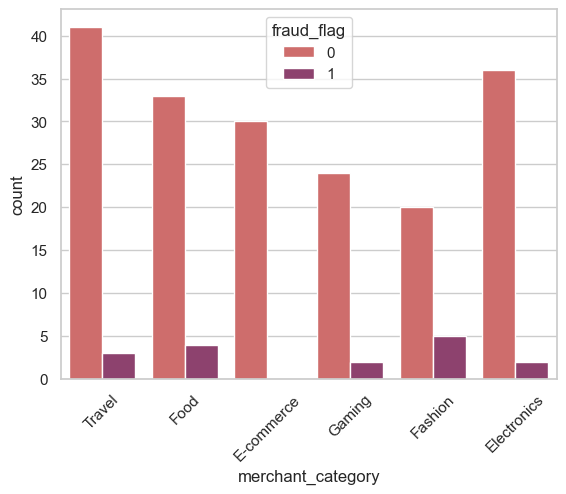

In [10]:
sns.countplot(data=df, x="merchant_category", hue="fraud_flag", palette="flare")
plt.xticks(rotation=45)
plt.show()

## Fraud Trend by Transaction Hour

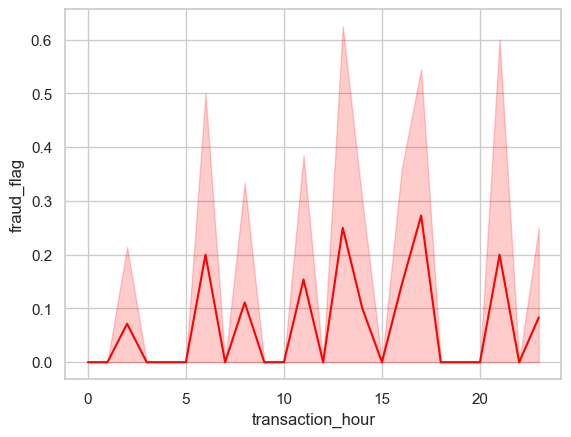

In [11]:
sns.lineplot(data=df, x="transaction_hour", y="fraud_flag", color="red")
plt.show()

## Correlation Heatmap

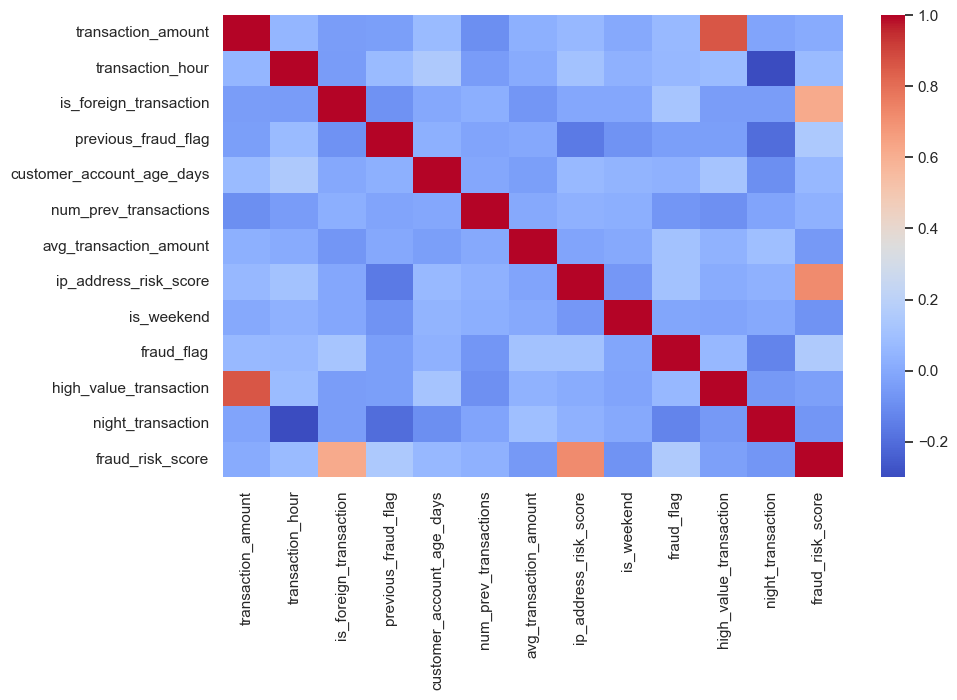

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.show()

## Feature Relationship Analysis

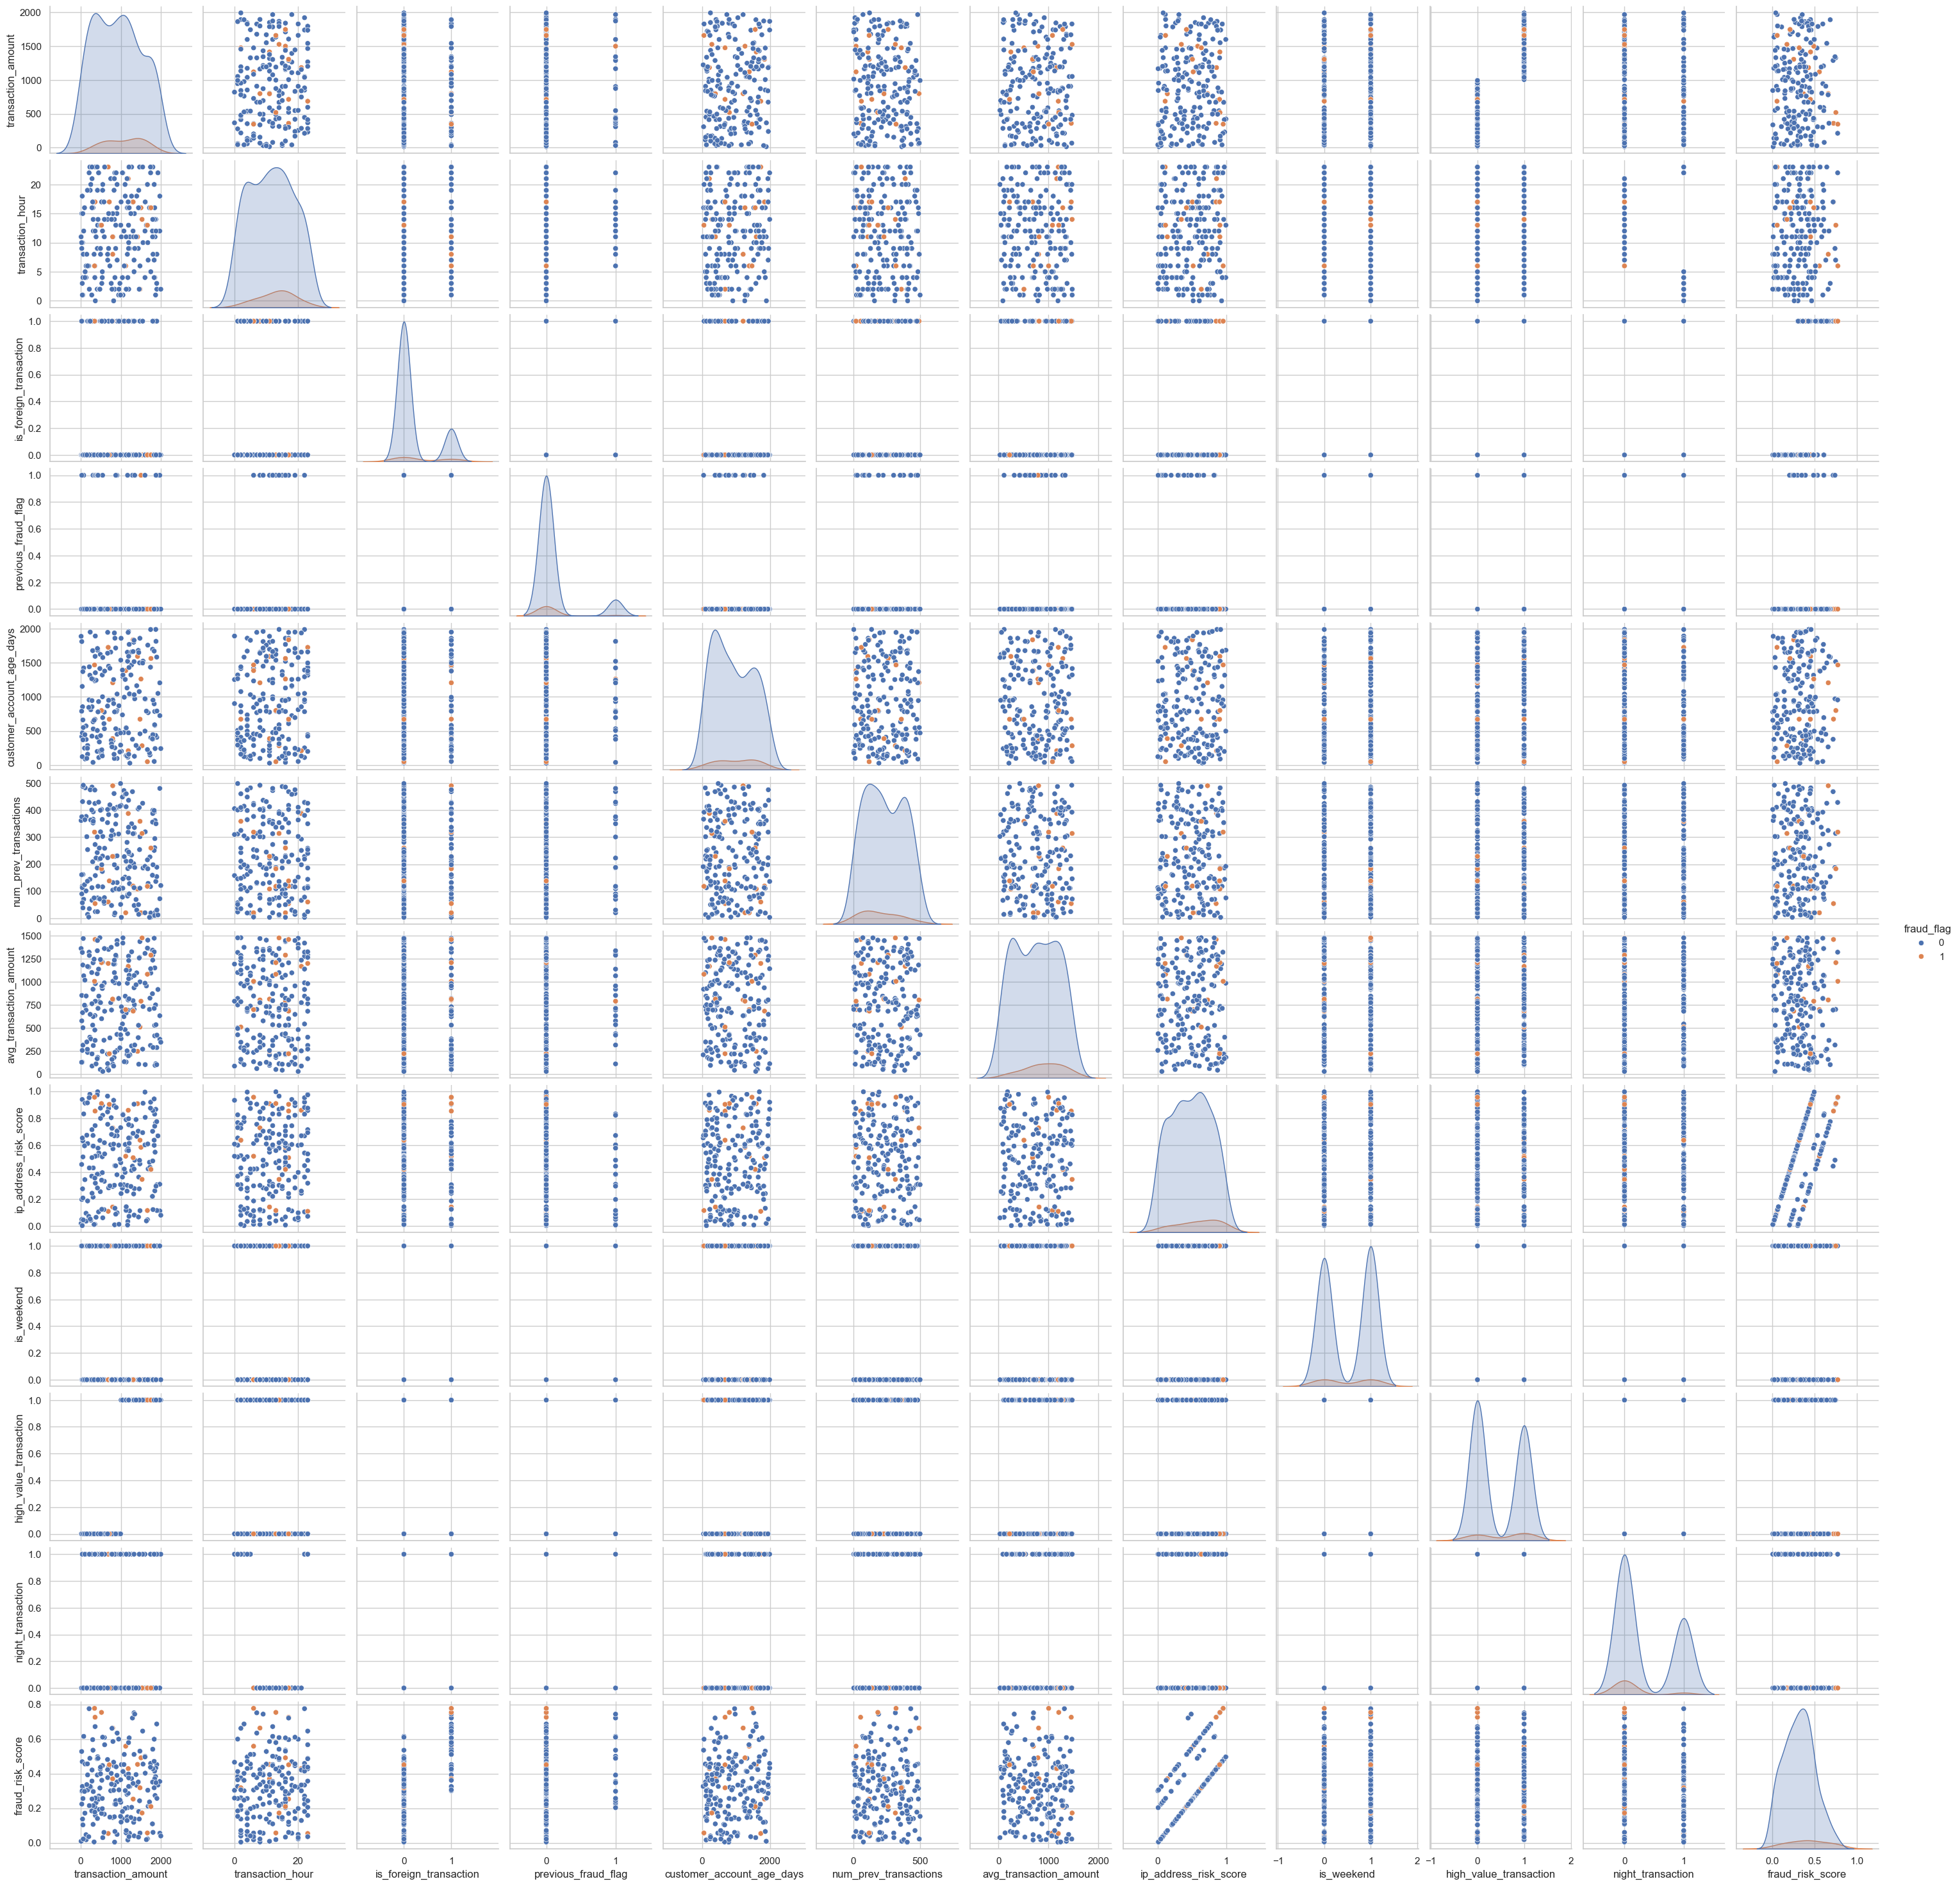

In [13]:
sns.pairplot(df, hue="fraud_flag")

## IP Risk Score vs Fraud

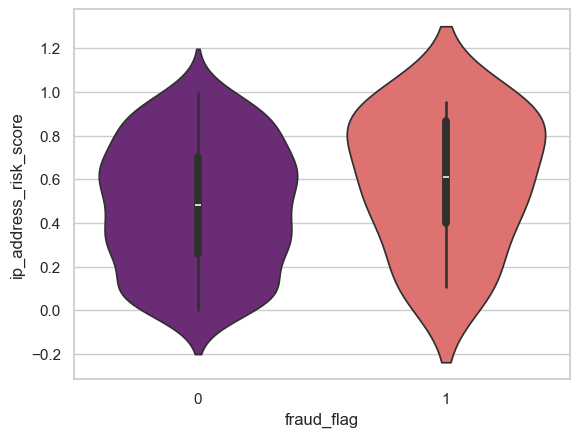

In [14]:
sns.violinplot(data=df, x="fraud_flag", y="ip_address_risk_score", palette="magma")
plt.show()

##  Hexbin Plot

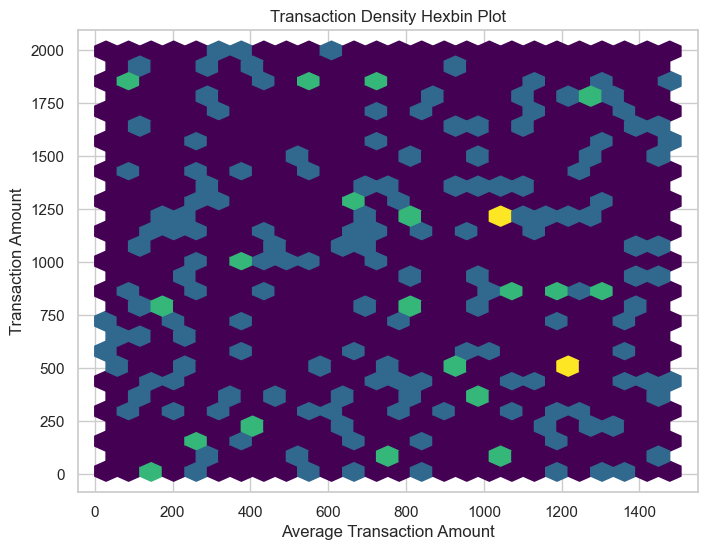

In [15]:
plt.figure(figsize=(8,6))

plt.hexbin(df["avg_transaction_amount"], df["transaction_amount"], gridsize=25, cmap="viridis")

plt.xlabel("Average Transaction Amount")
plt.ylabel("Transaction Amount")
plt.title("Transaction Density Hexbin Plot")

plt.show()

##  Bubble Plot

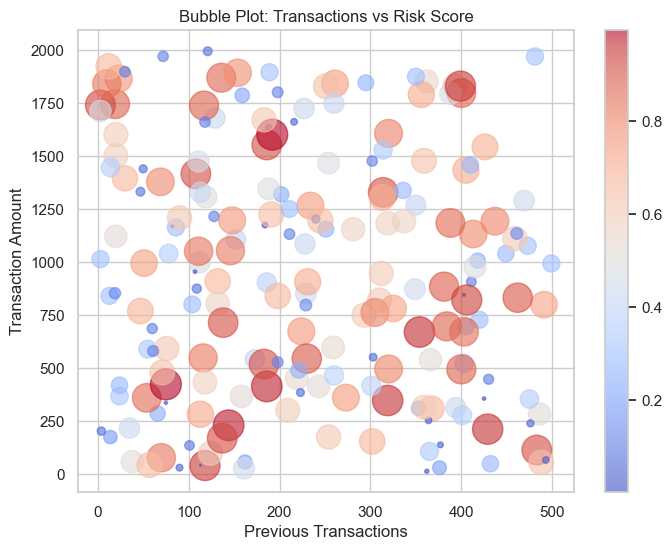

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["num_prev_transactions"],
    df["transaction_amount"],
    s=df["ip_address_risk_score"]*500,
    c=df["ip_address_risk_score"],
    cmap="coolwarm",
    alpha=0.6
)

plt.xlabel("Previous Transactions")
plt.ylabel("Transaction Amount")

plt.title("Bubble Plot: Transactions vs Risk Score")

plt.colorbar()

plt.show()

##  KDE Plot

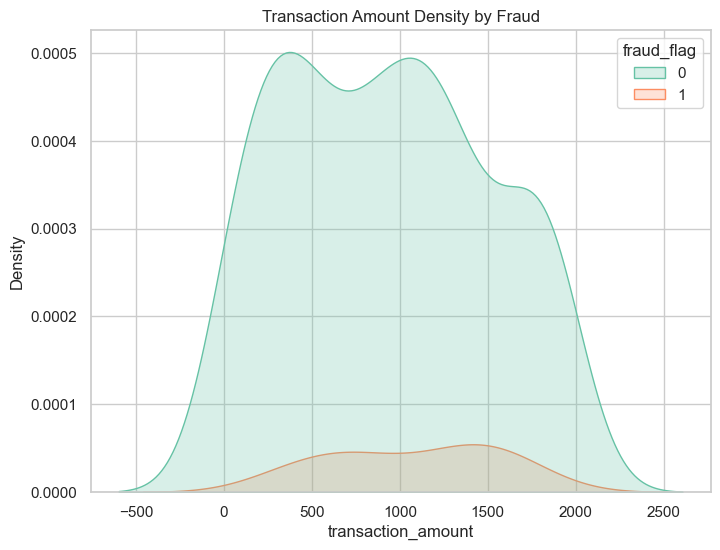

In [17]:
plt.figure(figsize=(8,6))

sns.kdeplot(
    data=df,
    x="transaction_amount",
    hue="fraud_flag",
    fill=True,
    palette="Set2"
)

plt.title("Transaction Amount Density by Fraud")

plt.show()

##  Boxen Plot (Advanced Seaborn)

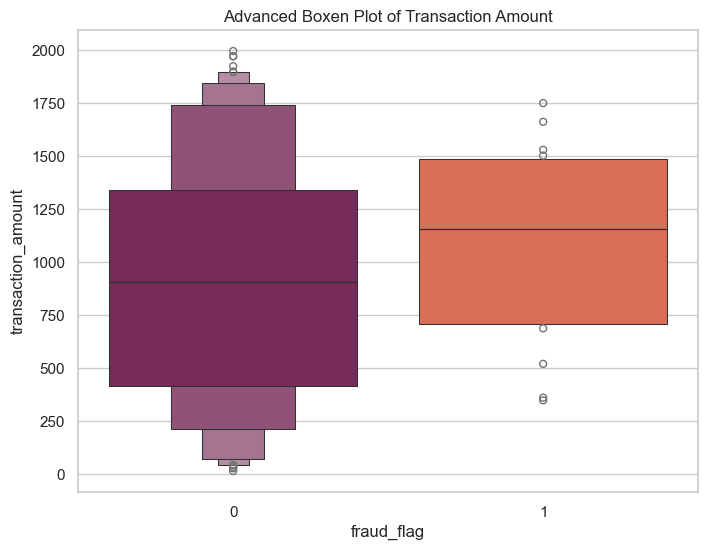

In [18]:
plt.figure(figsize=(8,6))

sns.boxenplot(
    data=df,
    x="fraud_flag",
    y="transaction_amount",
    palette="rocket"
)

plt.title("Advanced Boxen Plot of Transaction Amount")

plt.show()

##  Strip Plot

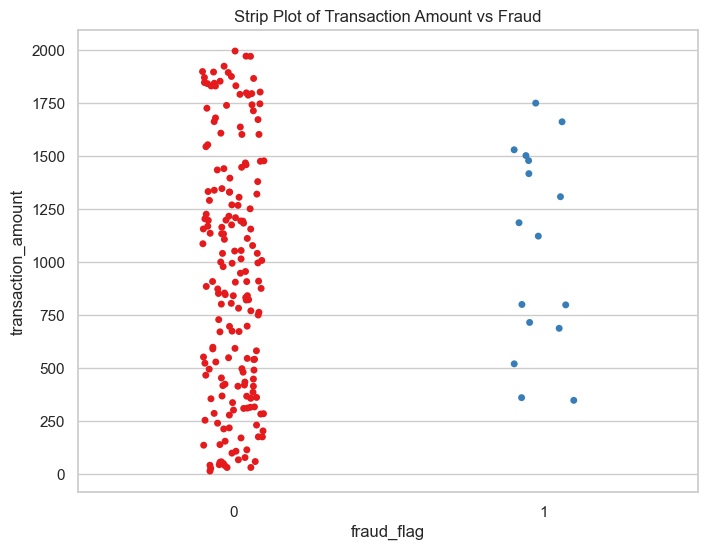

In [19]:
plt.figure(figsize=(8,6))

sns.stripplot(
    data=df,
    x="fraud_flag",
    y="transaction_amount",
    palette="Set1",
    jitter=True
)

plt.title("Strip Plot of Transaction Amount vs Fraud")

plt.show()

##  Swarm Plot

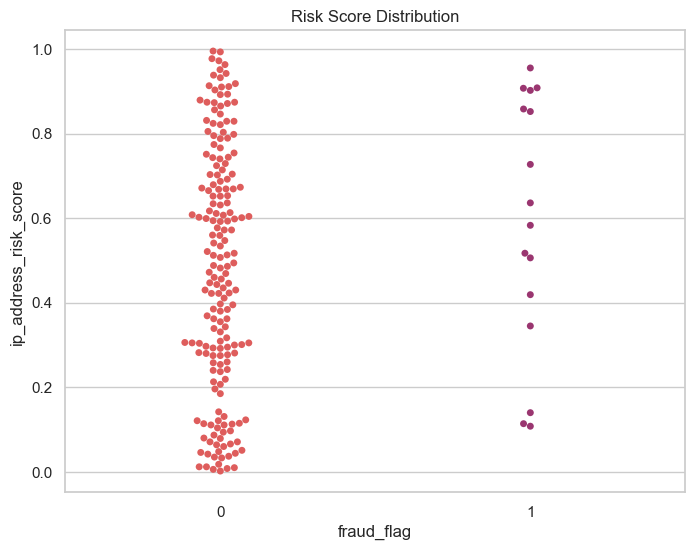

In [20]:
plt.figure(figsize=(8,6))

sns.swarmplot(
    data=df,
    x="fraud_flag",
    y="ip_address_risk_score",
    palette="flare"
)

plt.title("Risk Score Distribution")

plt.show()

##  Ridge Style Distribution

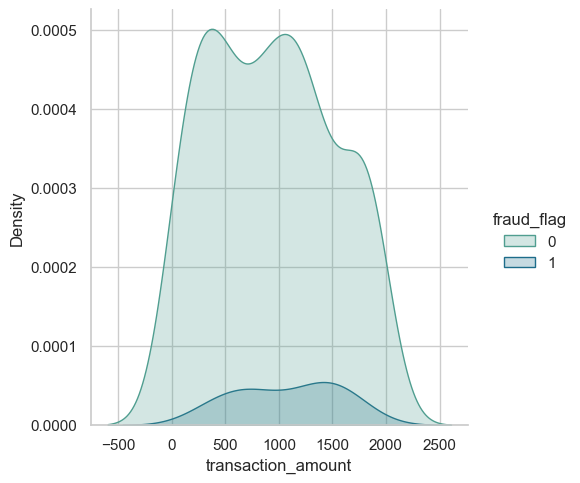

In [21]:
sns.displot(
    data=df,
    x="transaction_amount",
    hue="fraud_flag",
    kind="kde",
    fill=True,
    palette="crest"
)

## Fraud Detection Visualization Dashboard

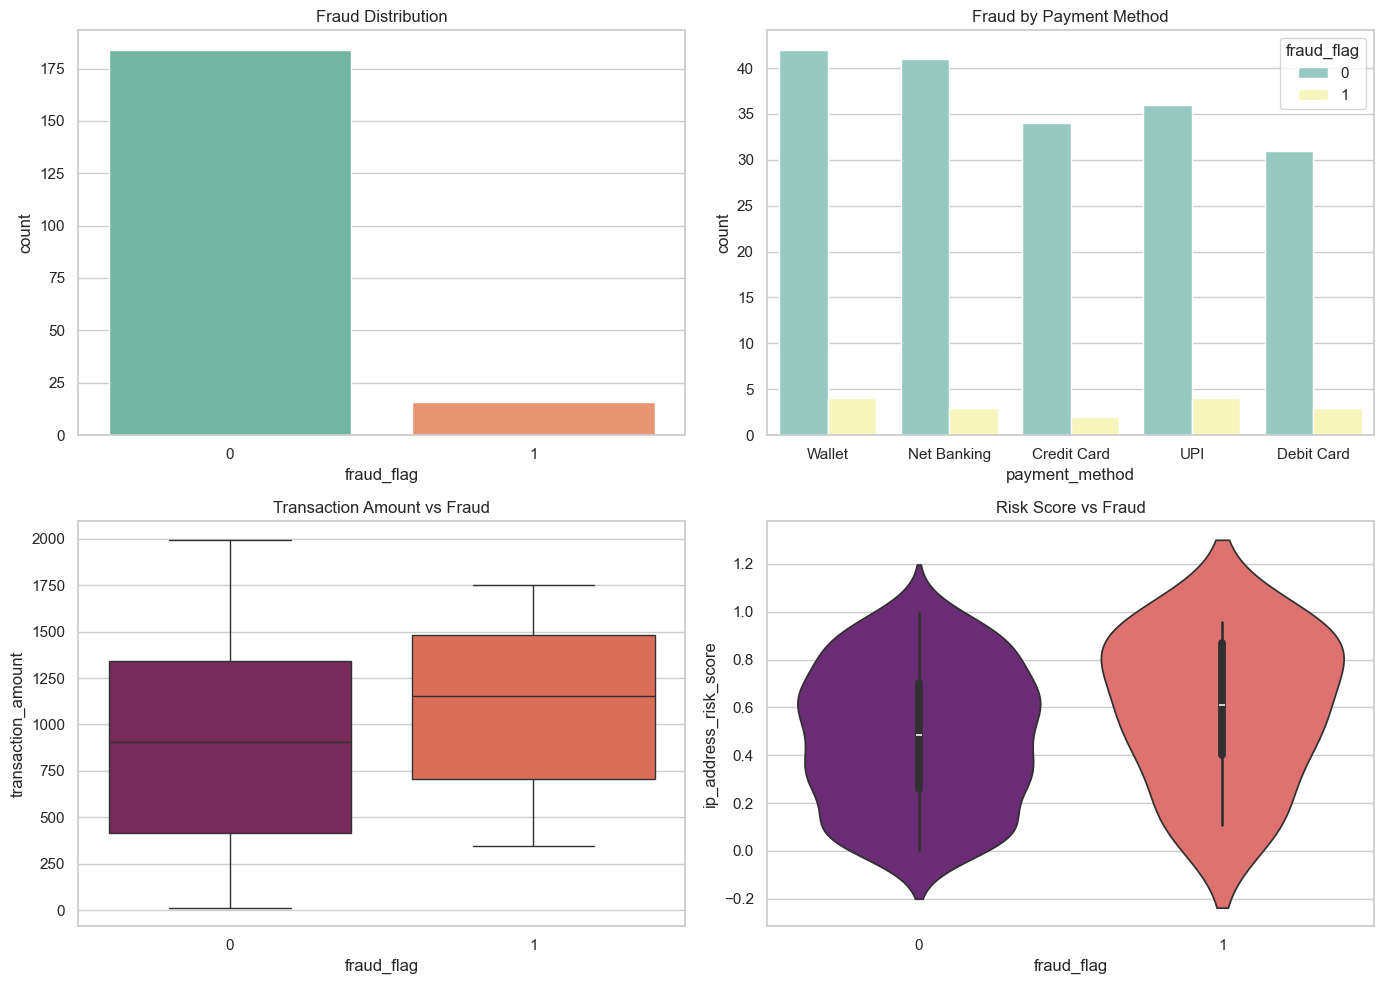

In [22]:
fig, axes = plt.subplots(2,2, figsize=(14,10))

sns.countplot(
    data=df,
    x="fraud_flag",
    ax=axes[0,0],
    palette="Set2"
)

axes[0,0].set_title("Fraud Distribution")

sns.countplot(
    data=df,
    x="payment_method",
    hue="fraud_flag",
    ax=axes[0,1],
    palette="Set3"
)

axes[0,1].set_title("Fraud by Payment Method")

sns.boxplot(
    data=df,
    x="fraud_flag",
    y="transaction_amount",
    ax=axes[1,0],
    palette="rocket"
)

axes[1,0].set_title("Transaction Amount vs Fraud")

sns.violinplot(
    data=df,
    x="fraud_flag",
    y="ip_address_risk_score",
    ax=axes[1,1],
    palette="magma"
)

axes[1,1].set_title("Risk Score vs Fraud")

plt.tight_layout()

plt.show()

##  Business Insights

• Fraud transactions often occur during late night hours.

• Foreign transactions show higher fraud probability.

• Higher IP risk scores strongly correlate with fraudulent activities.

• High value transactions show increased fraud risk.

• Certain payment methods experience more fraud attempts.


##  Final Summary

This project explored patterns in online payment transactions to understand
fraud behaviour using data science techniques.

Through exploratory data science and visualization, multiple risk indicators
were identified including transaction timing, payment method, transaction
amount, and risk scores.

These insights can help financial institutions improve fraud detection
systems and enhance transaction security.